In [4]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import subprocess
import xarray as xr
import scipy.ndimage as ndi
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from src.saving import *
from src.loading import *
from src.plotting import *
from src.secrets import GPM_PASS, GPM_USER

In [5]:
gpm_stats_all = load_gpm_feature_stats()
gpm_stats = gpm_stats_all.filter(
    ((190<=pl.col('number_pixels'))&(pl.col('number_pixels')<=200))
)
print(f'Found {gpm_stats.shape[0]} total PFs')

Found 603 total PFs


In [49]:
def _filter_stats(df, expr_ranges):
    conditions = []
    for expr, (low, high) in expr_ranges:
        conditions.append((expr >= low) & (expr <= high))

    mask = pl.all_horizontal(conditions)
    filtered_df = df.filter(mask)
    assert filtered_df.shape[0] > 0
    return filtered_df

def _download_and_extract_feature(ex_pf):
    # Download file if needed
    f_parts = ex_pf['gpm_filename'].item().split('/')[5:]
    f = "/".join(f_parts)
    outfile = DATA_DIR / f_parts[-1]
    if not os.path.exists(outfile):
        user = GPM_USER
        pwd = GPM_PASS
        url = f"http://gpm.atmos.washington.edu/{f}"
        subprocess.run(
            ["wget", "-q", "--user", user, "--password", pwd, url, "-O", outfile],
            check=True,
        )
    # Read in file and extract feature
    swath = xr.open_dataset(outfile).squeeze()
    labels, _ = ndi.label(swath['near_surf_rain']>1, structure = [[1,1,1],[1,1,1],[1,1,1]])
    label_slices = ndi.find_objects(labels)
    labels_da = swath['near_surf_rain'].copy(data=labels)
    pf_id = ex_pf['feature_id'].item()
    bounding_dict = {
        d: sl for d, sl in zip(labels_da.dims, label_slices[pf_id-1])
    }
    feature_data = swath.where((labels_da==pf_id), drop=False).isel(bounding_dict)
    return feature_data

def _plot_example_pf(pf_df, plot_title=None, pad_degs=1):
    fig, ax = plt.subplots(
        figsize=(6,6),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )
    pf = _download_and_extract_feature(pf_df)
    # Plot the precipitation rates
    cmap = discrete_cmap(
        combine_cmaps("winter", "autumn", split=0.5),
        N=25
    )
    norm = colors.LogNorm(vmin=1, vmax=100) 
    im = pf.near_surf_rain.plot(
        ax=ax, 
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        add_colorbar=False
    )
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
    cbar.set_label("Precip rate (mm/hr)", fontsize=14)
    cbar.ax.tick_params(labelsize=14)
    
    #
    # Plot the principal core
    #
    core_mask = (pf.near_surf_rain >= 10)
    structure = np.ones((3, 3), dtype=int) 
    core_labels_arr, core_count = ndi.label(core_mask.data, structure=structure)
    assert(core_count>0)
    
    # Find the largest core
    sizes = ndi.sum(core_mask.data, labels=core_labels_arr, index=range(1, core_count + 1))
    largest_label = int(np.argmax(sizes) + 1)
    largest_mask = xr.DataArray(
        (core_labels_arr == largest_label),
        coords=core_mask.coords, dims=core_mask.dims
    )
    largest_mask.plot.contourf(
        ax=ax,
        levels=[-0.5, 0.5, 1.5],
        hatches=['', '///'],   # no hatch for 0, slashes for 1
        colors='none',         # only hatches, no color fill
        add_colorbar=False
    )
    # Make a dummy patch for legend purposes
    hatch_patch = mpatches.Patch(
        facecolor='none', edgecolor='k', hatch='///', label='Largest core'
    )
    ax.legend(handles=[hatch_patch], loc='upper left')

    # Add padding around PF center
    clat = pf_df['mean_latitude'].item()
    clon = pf_df['mean_longitude'].item()
    pad_degs = 1  # degrees half-width/height
    lat_min = max(-90, clat - pad_degs)
    lat_max = min(90,  clat + pad_degs)
    lon_min = (clon - pad_degs)
    lon_max = (clon + pad_degs)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.set_facecolor("0.75")  # dark gray map background
    im.cmap.set_bad("0.75")   # make NaN areas match the background

    # Add some annotations of PF statistics
    def _area_factor():
        RE = 6378
        return (RE * np.deg2rad(0.05))**2
    
    s = (
        fr"$A = {pf_df['number_pixels'].item() * _area_factor():0.0f}$ km$^2$" + "\n"
        fr"$\sigma_{{conv}} = {(pf_df['number_10mmhr_pixels'] / pf_df['number_pixels']).item():0.2f}$" + "\n"
        fr"$\rho_{{conv}} = {(pf_df['largest_10mmhr_cluster'] / pf_df['number_10mmhr_pixels']).item():0.2f}$" + "\n"
        f"MaxPr: {pf_df['max_precip'].item():0.1f}mm/h"
    )
    ax.text(
        0.2,0.875, 
        s=s,
        transform=ax.transAxes, 
        fontsize=12,
        linespacing=1.5,
        verticalalignment='top',
        horizontalalignment='center',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', boxstyle='round,pad=0.1')
    )

    # Add coastlines + gridlines
    ax.coastlines(linewidth=0.6)
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.75,
        alpha=0.5,
        linestyle="-",
        color='darkgray'
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = mticker.MultipleLocator(0.25)   # 2° lon ticks
    gl.ylocator = mticker.MultipleLocator(0.25)   # 2° lat ticks
    gl.xlabel_style = {"size": 14, "rotation": 45, "ha": "right"}
    gl.ylabel_style = {"size": 14}

    ax.set_title(plot_title)
    return fig, ax

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/example_pf_low_concentration.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/example_pf_high_concentration.pdf as PDF ...


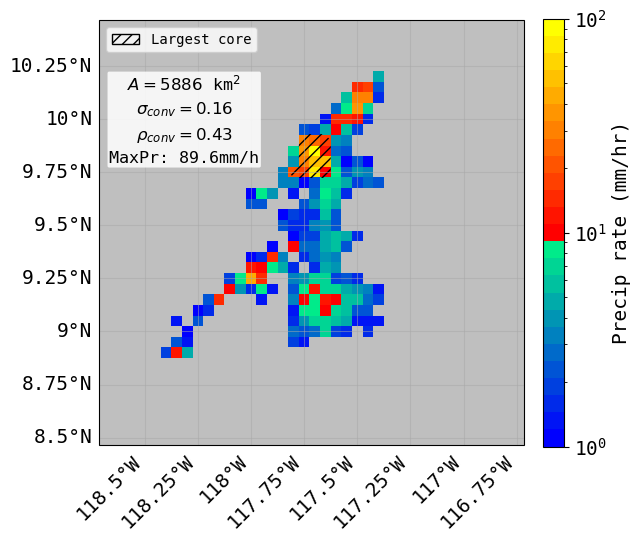

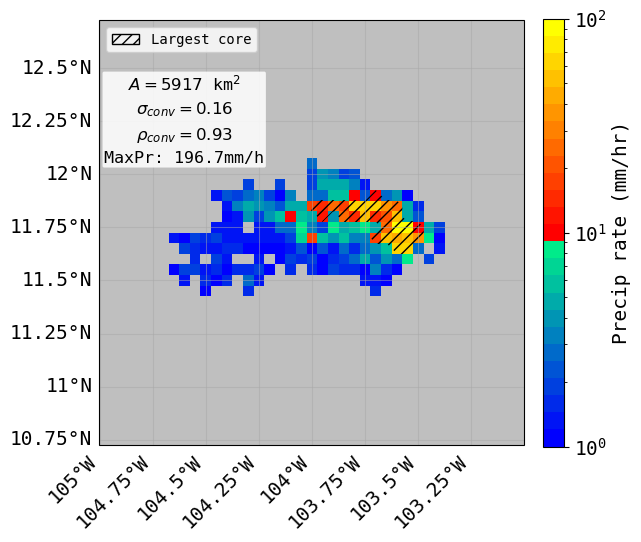

In [50]:
low_concentration = _filter_stats(
    gpm_stats,
    [
        (pl.col("number_10mmhr_pixels"), (30, 30)),
        (pl.col("largest_10mmhr_cluster") / pl.col("number_10mmhr_pixels"), (0.40, 0.45)),
    ]
)
fig, ax = _plot_example_pf(low_concentration[0], pad_degs=1)
save_figure(fig, "example_pf_low_concentration.pdf")

high_concentration = _filter_stats(
    gpm_stats,
    [
        (pl.col("number_10mmhr_pixels"), (30, 30)),
        (pl.col("largest_10mmhr_cluster") / pl.col("number_10mmhr_pixels"), (0.9, 0.95)),
    ]
)
fig, ax = _plot_example_pf(high_concentration[0], pad_degs=1)
save_figure(fig, "example_pf_high_concentration.pdf")